# Daisyworld: пространственная эволюция

Базовый опыт воспроизводит состояния сетки 30×30 на шагах 0, 5 и 45.
Чёрные маргаритки поглощают больше излучения, белые отражают его.

## Подготовка модели

In [1]:
using DrWatson
@quickactivate "DaisyworldLab"
include(srcdir("experiment_tools.jl"))

extinction_time (generic function with 1 method)

## Снимки заданных моментов

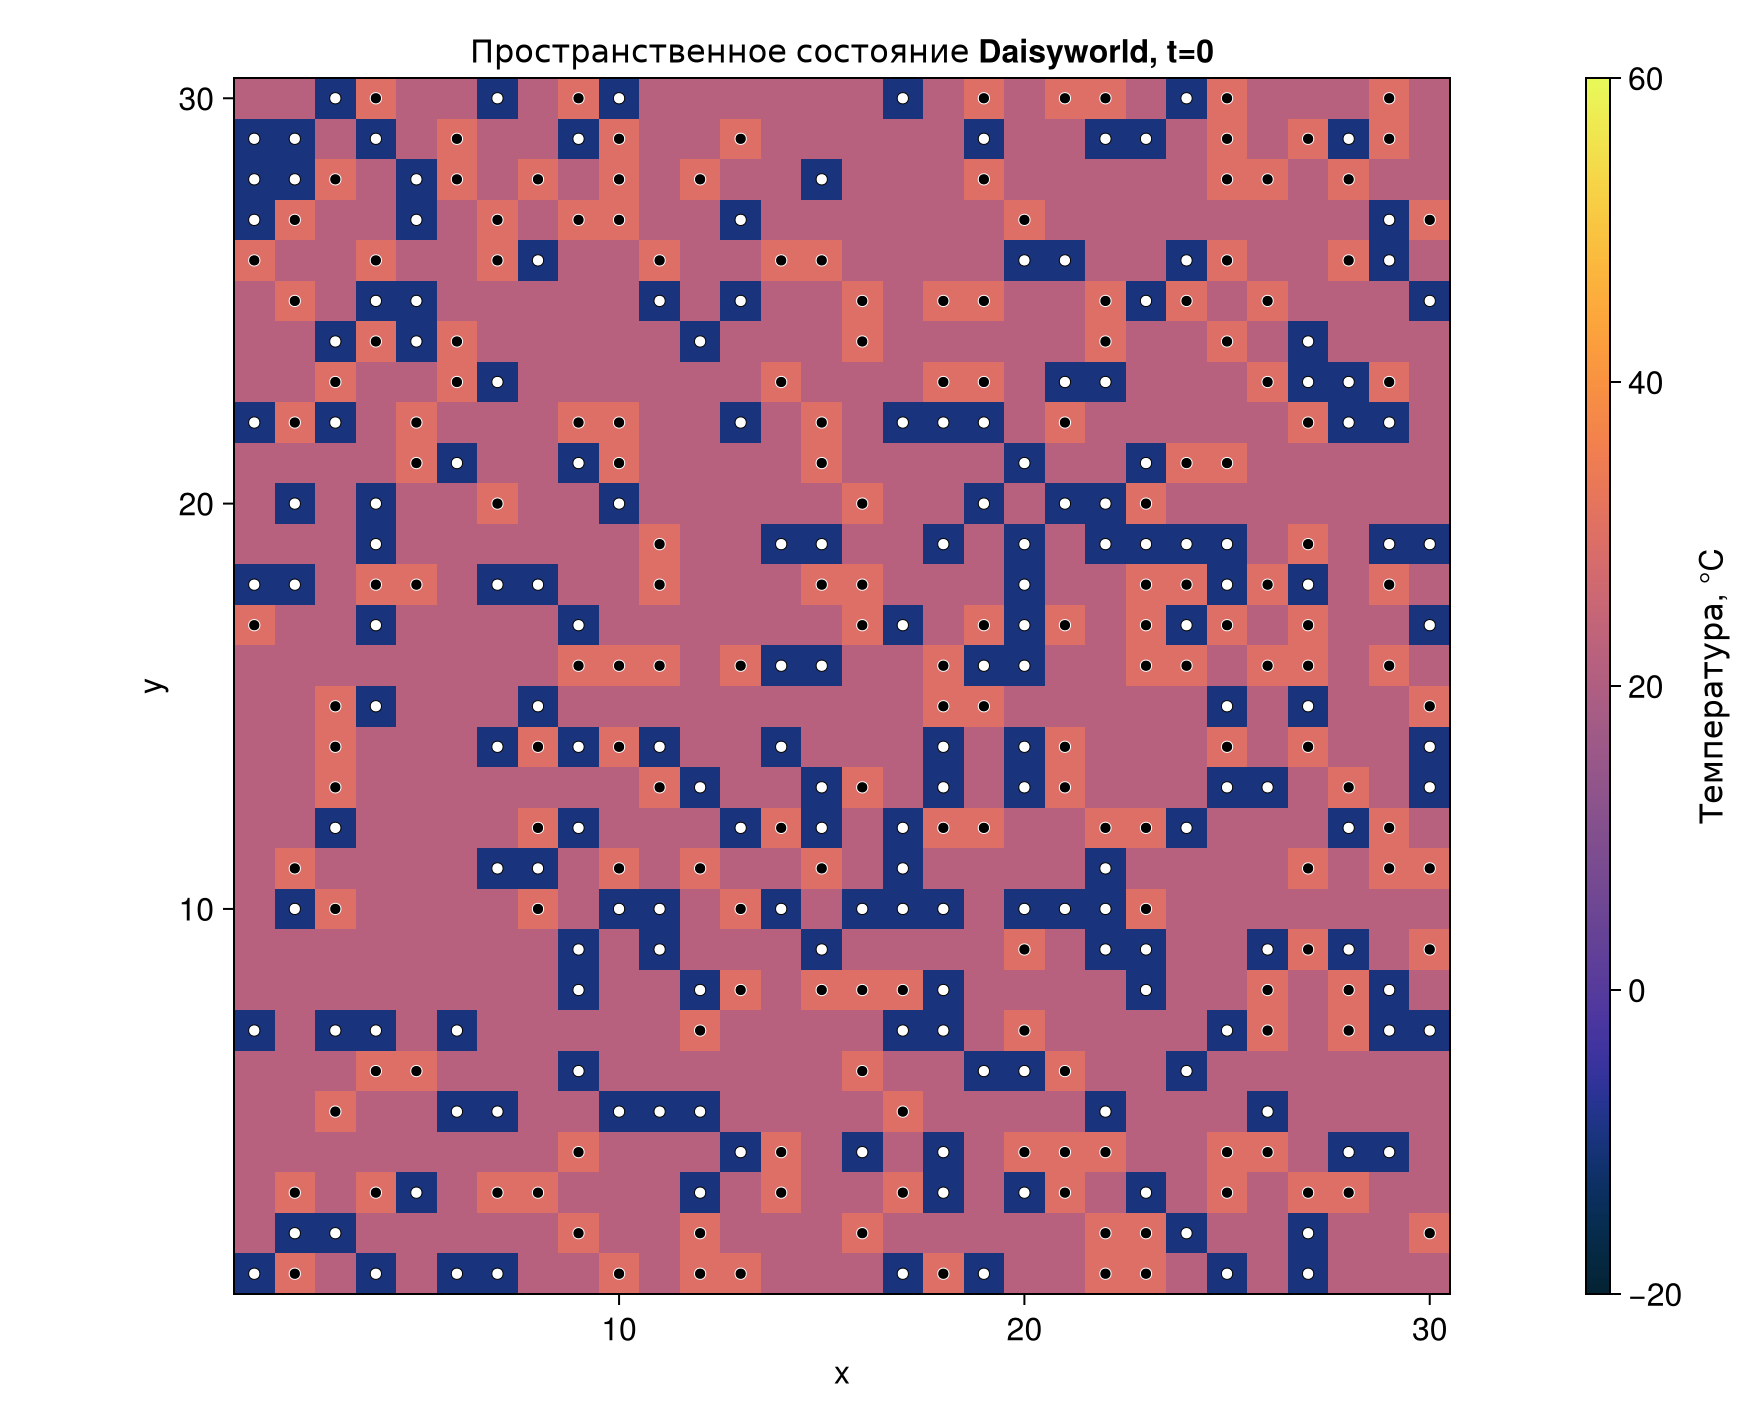

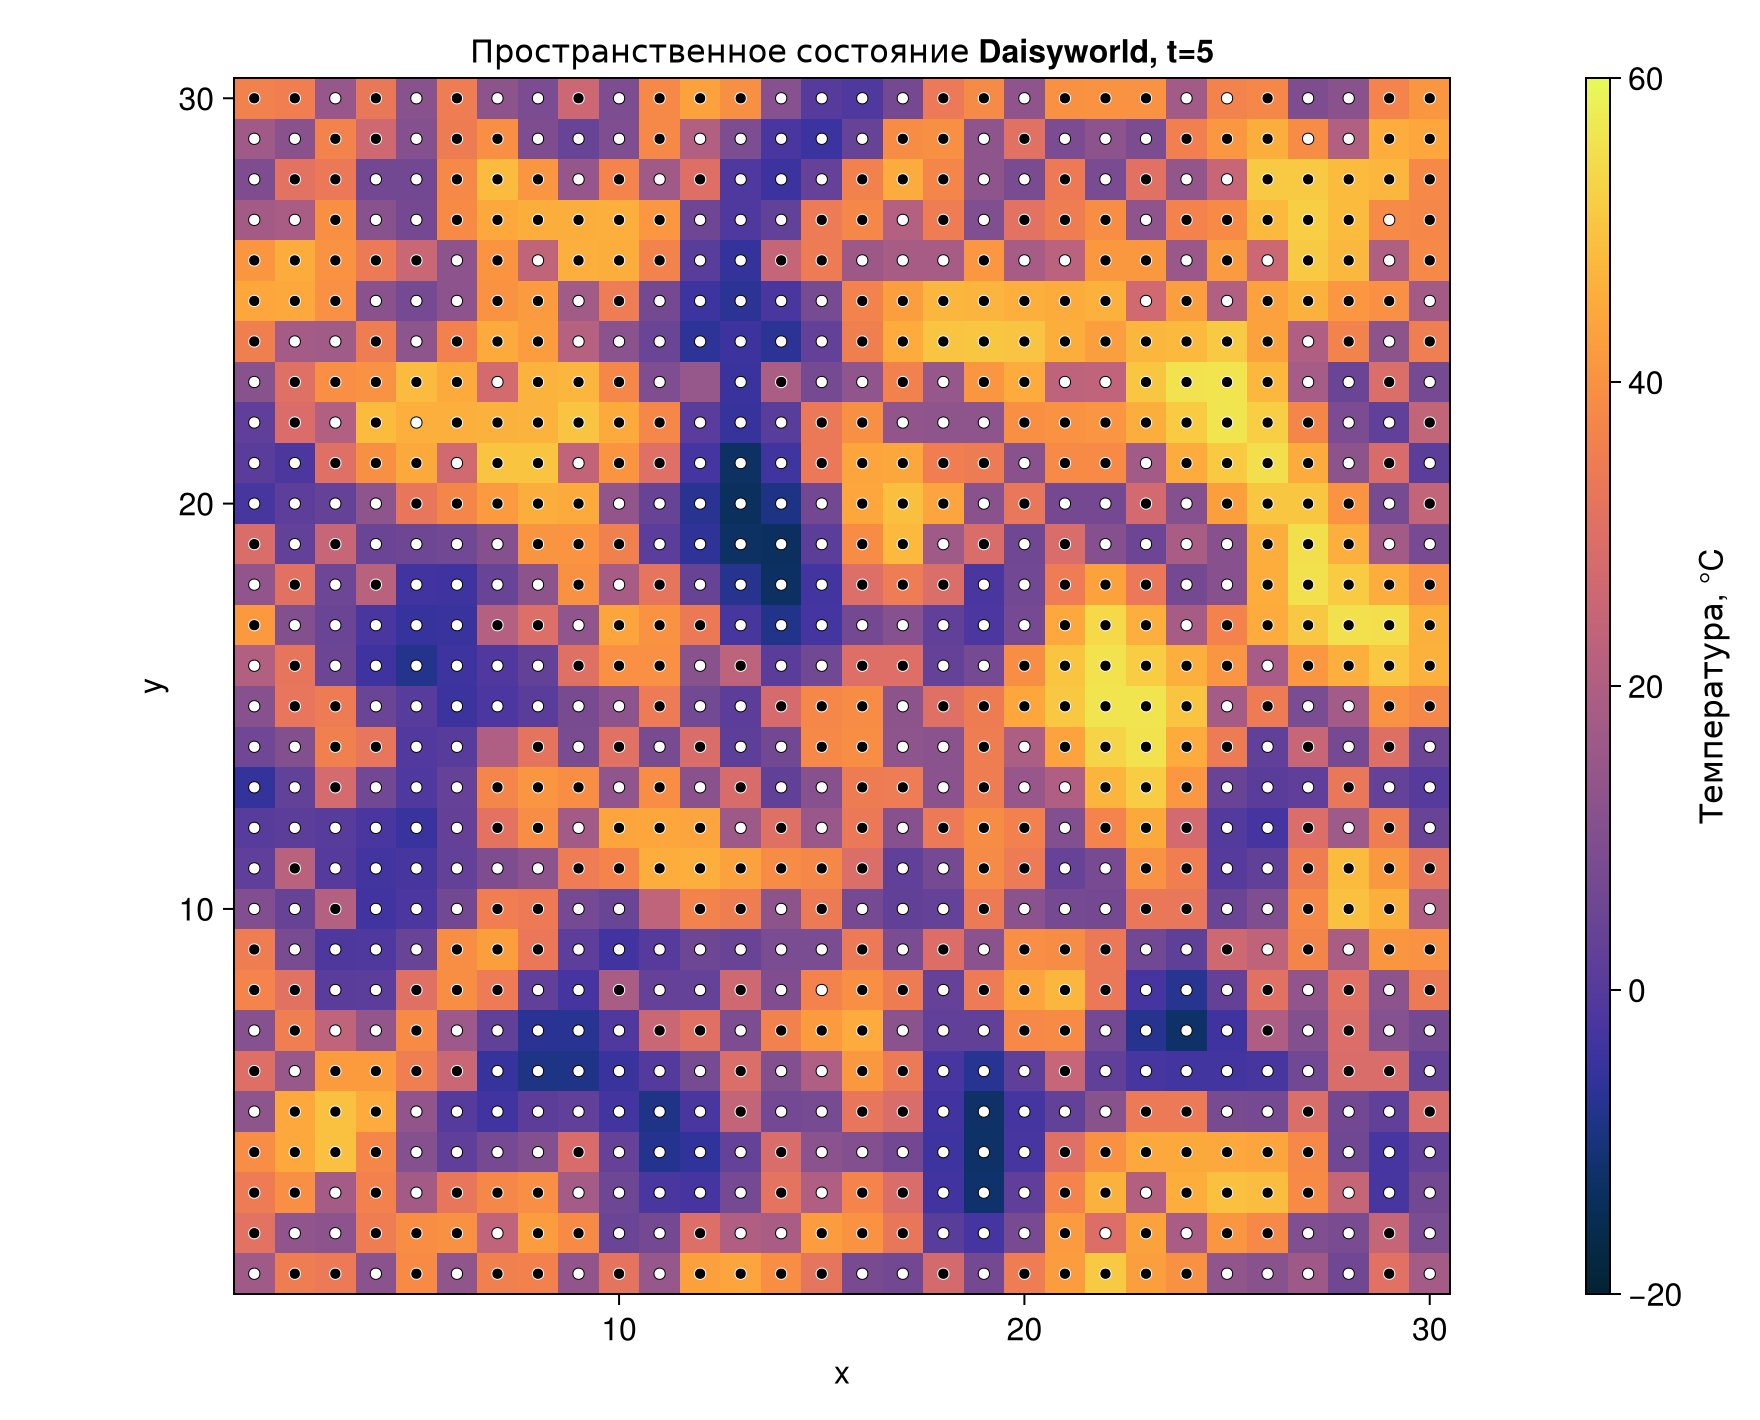

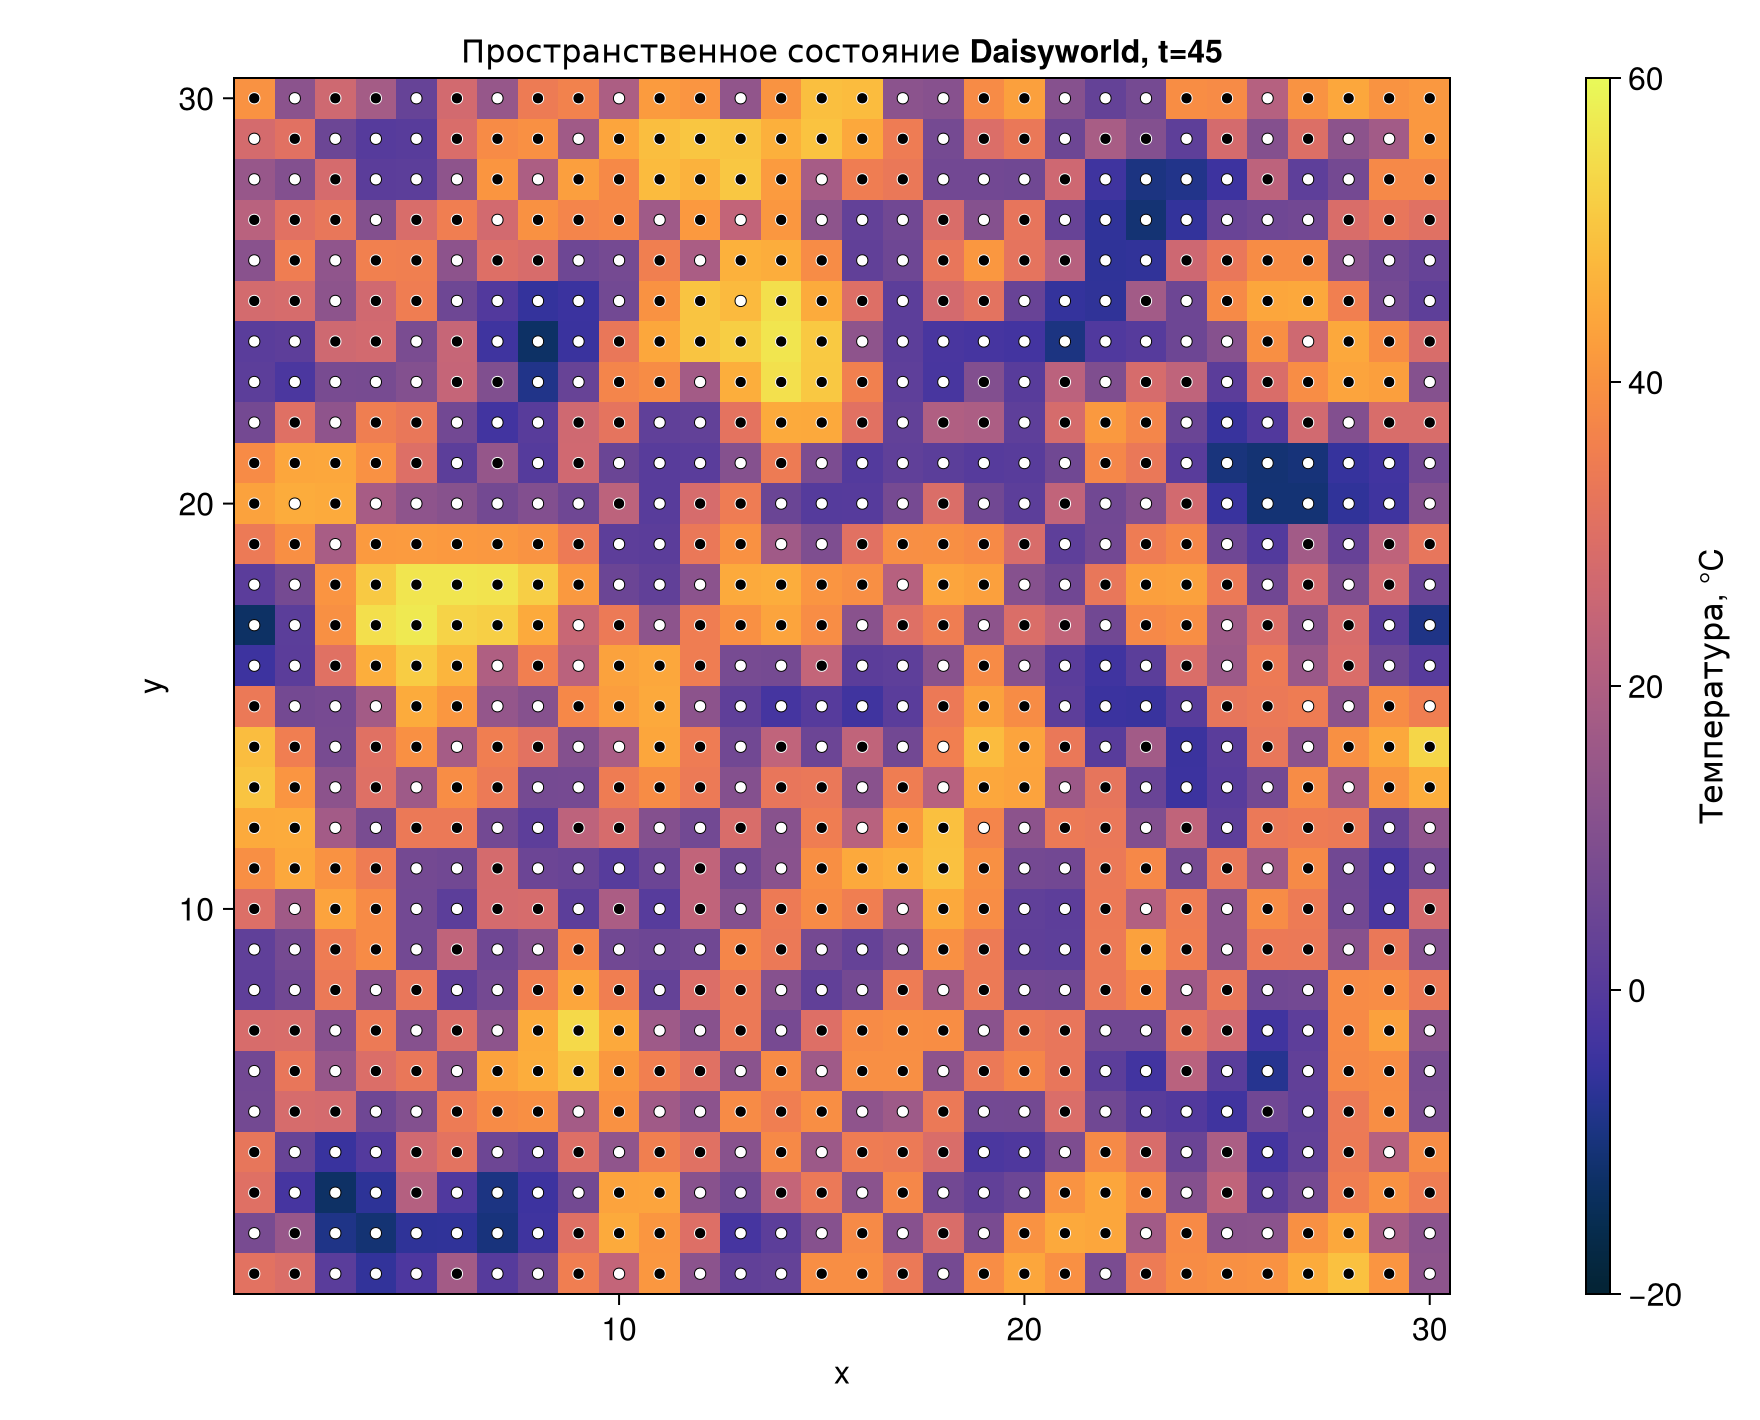

In [2]:
model = create_world(seed=165)
rows = NamedTuple[]
for target in (0, 5, 45)
    advance!(model, target - model.tick)
    push!(rows, observe(model))
    fig = snapshot_figure(model)
    save_figure(
        fig, "daisyworld", "step-$(lpad(target, 3, '0')).png";
        report_name="baseline-step-$(lpad(target, 3, '0')).png",
    )
    display(fig)
end

## Таблица наблюдений

In [3]:
summary = DataFrame(rows)
CSV.write(scenario_data("daisyworld", "snapshots.csv"), summary)
summary

Row,time,black,white,total,empty,temperature,luminosity,albedo,regulation_error
,Int64,Int64,Int64,Int64,Int64,Float64,Float64,Float64,Float64
1,0,180,180,360,540,16.9135,1.0,0.44,5.58646
2,5,457,440,897,3,23.0331,1.0,0.494944,0.533051
3,45,469,431,900,0,21.6992,1.0,0.489444,0.800804
